In [ ]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from google.colab import drive
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras import layers, models, backend as K
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/AI-ML-Health-Project/data')
JH_SEG_DIR = BASE_DIR / 'JH_seg_labels'
METADATA_PATH = BASE_DIR / 'IARCImageBankVIA' / 'Cases Meta data JH.xlsx'

VIA_MAPPING = {
    'Negative': 0,
    'Suspicious of cancer': 1,
    'Positive': 2,
    'Suspicious': 1
}

def load_metadata(metadata_path):
    df = pd.read_excel(metadata_path)
    df['VIA'] = df['VIA'].astype(str).str.strip()
    df['CaseNumber'] = df['CaseNumber'].astype(str).str.strip()
    df['CaseID'] = df['CaseID'].astype(str).str.strip()
    df['Label'] = df['VIA'].map(VIA_MAPPING)
    return df

metadata_df = load_metadata(METADATA_PATH)

def load_jh_data(jh_dir, metadata_df):
    image_paths = []
    mask_paths = []
    classification_labels = []
    case_ids = []
    folder_names = []


    caseid_to_label = {}
    jh_caseid_to_label = {}

    for _, row in metadata_df.iterrows():
        case_id = str(row['CaseID']).strip()
        label = row['Label']

        if pd.notna(label) and case_id and case_id != 'nan':
            caseid_to_label[case_id] = label
            if case_id.upper().startswith('JH'):
                jh_caseid_to_label[case_id.upper()] = label

    jh_path = Path(jh_dir)
    case_folders = [f for f in jh_path.iterdir() if f.is_dir()]

    for folder in case_folders:
        folder_name = folder.name.strip()
        img_file = folder / 'img.png'
        label_file = folder / 'label.png'
        label = None
        matched_case_id = None

        folder_name_upper = folder_name.upper()
        if folder_name_upper in caseid_to_label:
            label = caseid_to_label[folder_name_upper]
            matched_case_id = folder_name_upper
        elif folder_name_upper in jh_caseid_to_label:
            label = jh_caseid_to_label[folder_name_upper]
            matched_case_id = folder_name_upper

        if label is None and folder_name.startswith('JH'):
            for case_id, lbl in jh_caseid_to_label.items():
                if case_id == folder_name_upper:
                    label = lbl
                    matched_case_id = case_id
                    break

        if label is None and folder_name.startswith('JH'):
            for case_id, lbl in jh_caseid_to_label.items():
                if folder_name_upper in case_id or case_id in folder_name_upper:
                    label = lbl
                    matched_case_id = case_id
                    break

        image_paths.append(str(img_file))
        mask_paths.append(str(label_file))
        classification_labels.append(label)
        case_ids.append(matched_case_id if matched_case_id else 'Unknown')
        folder_names.append(folder_name)

    return (np.array(image_paths), np.array(mask_paths), np.array(classification_labels), np.array(case_ids),np.array(folder_names))

images, masks, labels, case_ids, folder_names = load_jh_data(JH_SEG_DIR, metadata_df)

# Segmentation

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred): return 1 - dice_coef(y_true, y_pred)

def mean_iou(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)
    return tf.reduce_mean(tf.keras.metrics.mean_iou(y_true, y_pred, 3))

def process_segmentation_data(image_path, mask_path, is_training=True):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224, 224))

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.image.resize(mask, (224, 224), method='nearest')
    mask = tf.cast(mask, tf.float32)

    if is_training:
        combined = tf.concat([img, mask], axis=-1)
        combined = tf.image.random_flip_left_right(combined)
        combined = tf.image.random_flip_up_down(combined)
        img, mask = tf.split(combined, [3, 3], axis=-1)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)


    img = tf.cast(img, tf.float32)
    mask = mask[..., 0]
    mask = tf.cast(mask > 100, tf.int32)
    mask = tf.one_hot(mask, depth=2)

    return img, mask

In [ ]:
def build_unet_binary(classifier_path):
    full_classifier = tf.keras.models.load_model(classifier_path)
    backbone = full_classifier.layers[0]

    layers_to_extract = ['block2b_add', 'block3b_add', 'block5c_add', 'block7a_project_bn']
    enc_outputs = [backbone.get_layer(name).output for name in layers_to_extract]
    encoder = models.Model(inputs=backbone.input, outputs=enc_outputs)
    s1, s2, s3, bridge = encoder(backbone.input)

    x = layers.Conv2DTranspose(256, 3, strides=2, padding='same')(bridge)
    x = layers.Concatenate()([x, s3])
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, s2])
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, s1])
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same')(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(16, 3, strides=2, padding='same')(x)
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32')(x)
    return models.Model(inputs=backbone.input, outputs=outputs)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return .1*bce + dice

def process_binary_seg(image_path, mask_path, is_training=True):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)
    mask = tf.image.resize(mask, (224, 224), method='nearest')
    mask = tf.cast(mask, tf.float32)

    if is_training:
        combined = tf.concat([img, mask], axis=-1)
        combined = tf.image.random_flip_left_right(combined)
        img, mask = tf.split(combined, [3, 3], axis=-1)

    red_channel = mask[..., 0]
    mask_bin = tf.cast(red_channel > 50, tf.float32)
    mask_bin = tf.expand_dims(mask_bin, axis=-1)
    return img, mask_bin

def create_binary_seg_dataset(paths, masks, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, masks))
    if is_training: ds = ds.shuffle(buffer_size=1000)

    ds = ds.map(lambda x, y: process_binary_seg(x, y, is_training=is_training), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_binary_seg_dataset(train_paths, train_masks, is_training=True)
val_ds = create_binary_seg_dataset(val_paths, val_masks, is_training=False)
test_ds = create_binary_seg_dataset(test_paths, test_masks, is_training=False)

unet_model = build_unet_binary('/content/efficientnetb0_classifier.keras')
unet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=bce_dice_loss, metrics=['binary_accuracy', dice_coef])

history = unet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint('efficientnet_unet_best.keras', save_best_only=True, monitor='val_dice_coef', mode='max'),
        tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    ]
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 11s/step - binary_accuracy: 0.9523 - dice_coef: 0.1328 - loss: 0.8852 - val_binary_accuracy: 0.9555 - val_dice_coef: 0.1604 - val_loss: 0.8541
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 9s/step - binary_accuracy: 0.9500 - dice_coef: 0.1678 - loss: 0.8474 - val_binary_accuracy: 0.9521 - val_dice_coef: 0.1864 - val_loss: 0.8274
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 10s/step - binary_accuracy: 0.9353 - dice_coef: 0.2071 - loss: 0.8100 - val_binary_accuracy: 0.9468 - val_dice_coef: 0.2073 - val_loss: 0.8065
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 8s/step - binary_accuracy: 0.9495 - dice_coef: 0.1872 - loss: 0.8293 - val_binary_accuracy: 0.9428 - val_dice_coef: 0.2288 - val_loss: 0.7848
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 9s/step - binary_accuracy: 0.9402 - dice_coef: 0.2730 - loss: 0.7426 - val_binary_accuracy: 0.9474 - val_dice_coef: 0.2644 - val_loss: 0.7480
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 10s/step - binary_accuracy: 0.9440 - dice_

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred_f = tf.cast(y_pred > 0.5, tf.float32)
    y_true_f = tf.cast(y_true, tf.float32)

    y_true_f = tf.reshape(y_true_f, [-1])
    y_pred_f = tf.reshape(y_pred_f, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

unet_model.compile(optimizer='adam', loss=bce_dice_loss, metrics=['binary_accuracy', dice_coef, iou_metric])

print("Evaluating on Test Set...")
results = unet_model.evaluate(test_ds, return_dict=True)
results

Evaluating on Test Set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - binary_accuracy: 0.9545 - dice_coef: 0.5148 - iou_metric: 0.3777 - loss: 0.5219


{'binary_accuracy': 0.9545250535011292,
 'dice_coef': 0.5147699117660522,
 'iou_metric': 0.37766212224960327,
 'loss': 0.5219296813011169}

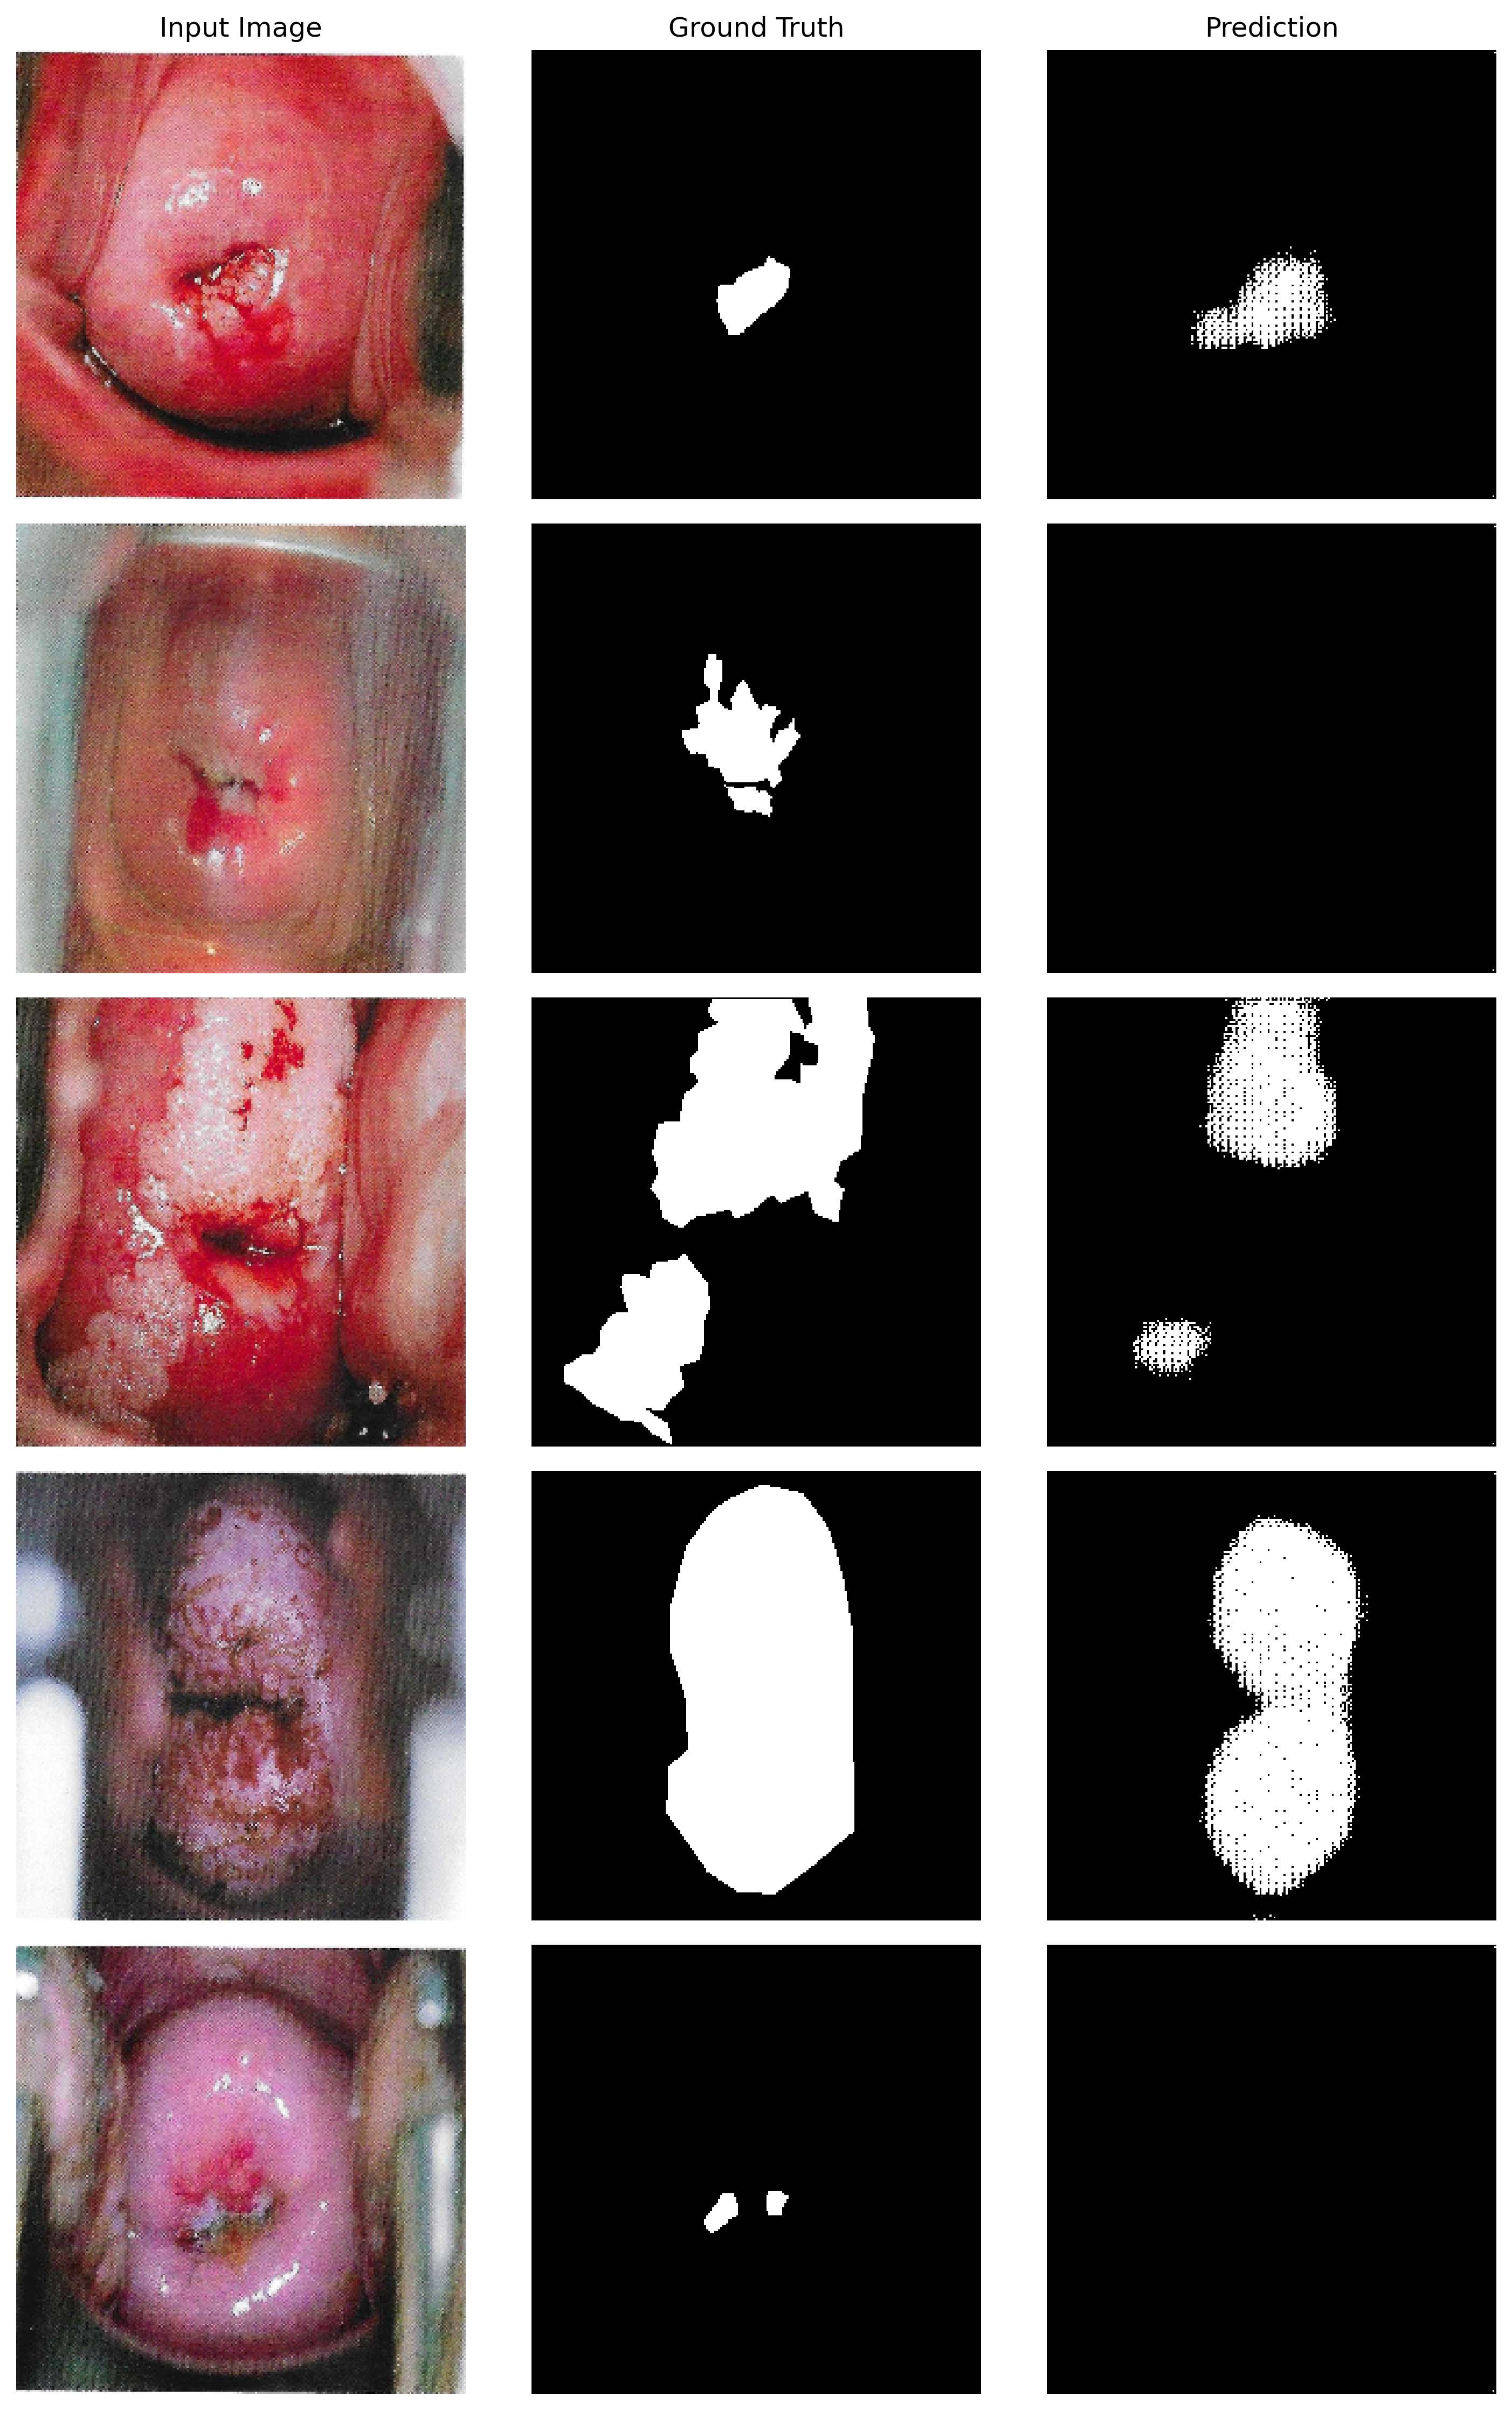

In [ ]:
samples = []
for images, masks in test_seg_ds:
    # Run model on 5 images from testing set
    preds = unet_model.predict(images, verbose=0)
    for i in range(len(images)):
        if np.sum(masks[i]) > 0:
            samples.append((images[i], masks[i], preds[i]))
        if len(samples) >= 5: break
    if len(samples) >= 5: break

plt.figure(figsize=(10, 15)) # 5 rows

for i, (img, mask, pred) in enumerate(samples):
    img_disp = img.numpy().astype("uint8")
    true_mask = mask.numpy().squeeze()
    pred_mask = (pred > 0.5).astype("uint8").squeeze()

    # Column 1: Image
    plt.subplot(5, 3, i*3 + 1)
    plt.imshow(img_disp)
    plt.axis("off")
    if i == 0: plt.title("Input Image")

    # Column 2: Ground Truth
    plt.subplot(5, 3, i*3 + 2)
    plt.imshow(true_mask, cmap='gray')
    plt.axis("off")
    if i == 0: plt.title("Ground Truth")

    # Column 3: Prediction
    plt.subplot(5, 3, i*3 + 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.axis("off")
    if i == 0: plt.title("Prediction")

plt.tight_layout()
plt.show()

In [ ]:
unet_model.save('efficient_unet_final.keras')